<a href="https://colab.research.google.com/github/Nourin-Nusrat/CSE4261_DNN/blob/main/Assignment10/DNN_Assignment_10_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Autoencoder

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 16)  # latent space
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid(),  # Pixel values between 0 and 1
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

# Load MNIST Dataset

In [ ]:
transform = transforms.ToTensor()
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=128, shuffle=True)

# Initialize Model, Loss, Optimizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 40
for epoch in range(epochs):
    for images, _ in loader:
        images = images.to(device)
        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")
print("Training finished.\n")

Epoch [1/40], Loss: 0.0294
Epoch [2/40], Loss: 0.0237
Epoch [3/40], Loss: 0.0207
Epoch [4/40], Loss: 0.0159
Epoch [5/40], Loss: 0.0162
Epoch [6/40], Loss: 0.0153
Epoch [7/40], Loss: 0.0144
Epoch [8/40], Loss: 0.0139
Epoch [9/40], Loss: 0.0120
Epoch [10/40], Loss: 0.0125
Epoch [11/40], Loss: 0.0122
Epoch [12/40], Loss: 0.0117
Epoch [13/40], Loss: 0.0122
Epoch [14/40], Loss: 0.0119
Epoch [15/40], Loss: 0.0121
Epoch [16/40], Loss: 0.0120
Epoch [17/40], Loss: 0.0113
Epoch [18/40], Loss: 0.0105
Epoch [19/40], Loss: 0.0101
Epoch [20/40], Loss: 0.0095
Epoch [21/40], Loss: 0.0109
Epoch [22/40], Loss: 0.0101
Epoch [23/40], Loss: 0.0107
Epoch [24/40], Loss: 0.0108
Epoch [25/40], Loss: 0.0106
Epoch [26/40], Loss: 0.0093
Epoch [27/40], Loss: 0.0090
Epoch [28/40], Loss: 0.0095
Epoch [29/40], Loss: 0.0097
Epoch [30/40], Loss: 0.0094
Epoch [31/40], Loss: 0.0085
Epoch [32/40], Loss: 0.0092
Epoch [33/40], Loss: 0.0095
Epoch [34/40], Loss: 0.0086
Epoch [35/40], Loss: 0.0091
Epoch [36/40], Loss: 0.0091
E

# Generate Noise Vectors (mean=5, variance=1)

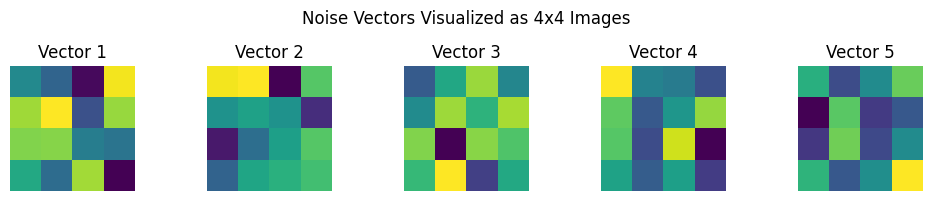

In [13]:
noise_vectors = torch.normal(mean=5.0, std=1.0, size=(5, 16))
plt.figure(figsize=(10, 2))
for i in range(5):
    vector_image = noise_vectors[i].reshape(4, 4).cpu().numpy()
    plt.subplot(1, 5, i + 1)
    plt.imshow(vector_image)
    plt.title(f"Vector {i+1}")
    plt.axis('off')

plt.suptitle("Noise Vectors Visualized as 4x4 Images")
plt.tight_layout()
plt.show()

# Plot the Results

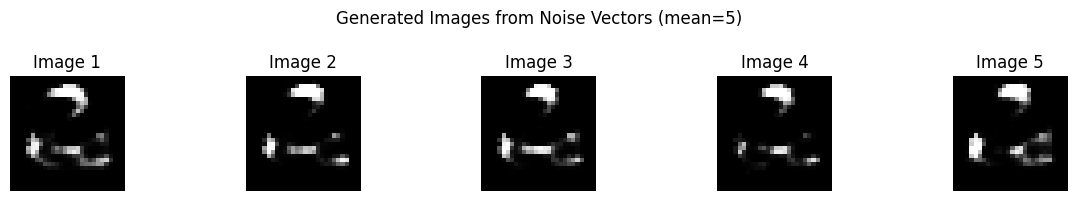

In [ ]:
with torch.no_grad():
    generated_images = model.decoder(noise_vectors).cpu()

plt.figure(figsize=(12, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.title(f"Image {i+1}")
    plt.axis('off')
plt.suptitle("Generated Images from Noise Vectors (mean=5)")
plt.tight_layout()
plt.show()